# HydroSeason: Rainfall Context — one AOI, both datasets

This notebook runs the whole thing from **an AOI and two dates**. One call
fetches everything:

- **Water** from Digital Earth Australia — the all-time WOfS statistics that
  define the analysis mask, plus the monthly water masks themselves
  (see [02_dea_acquisition.ipynb](02_dea_acquisition.ipynb) for what that
  involves).
- **Rainfall** from [SILO](https://www.longpaddock.qld.gov.au/silo/) —
  gridded daily climate data from the Queensland Government, aggregated to
  monthly totals over the same AOI.

The point of the notebook is what happens next: **rainfall is added as
context and is never allowed to influence the water analysis.** The regime,
route, hydrological-year boundaries, phases, events and low spells are all
decided from water alone, before rainfall is even loaded. Section 3 proves it
by re-running without rainfall and comparing.

**Requirements:** `pip install "hydroseason[stac]"`
**Network:** yes — DEA STAC *and* SILO.
**Runtime:** a few minutes on a cold cache; fast afterwards.

## 1. One call, both sources

In [1]:
from pathlib import Path

from hydroseason import run_hydroseason

AOI_PATH = Path("../data/fitzroy_kimberley_aoi.geojson")

START_DATE = "2015-01-01"
END_DATE = "2025-12-01"

# Shared with 02_dea_acquisition.ipynb -- if you ran that notebook, the WOfS
# acquisition below is already cached and this is quick.
CACHE_DIR = Path("output/02_dea_cache")

result = run_hydroseason(
    output_dir="output/03_rainfall_context",
    aoi=AOI_PATH,
    aoi_name="Fitzroy River (Kimberley, WA)",
    start_date=START_DATE,
    end_date=END_DATE,
    cache_dir=CACHE_DIR,
    fetch_rainfall=True,
)

print(f"Water source:     {result.source_kind}")
print(f"Rainfall source:  {result.rainfall_source}  ({result.rainfall_status})")
print(f"Months:           {len(result.extent)}")
print(f"Regime:           {result.analysis.regime.regime}")
print(f"Route:            {result.analysis.route}")

Water source:     dea_wofs
Rainfall source:  silo  (fetched)
Months:           132
Regime:           seasonal
Route:            per_year_detection


### What came back

Two independent monthly series over the same AOI and period: water extent
measured from satellite, and rainfall totals interpolated from gauges.

In [2]:
combined = result.extent[["extent_pct", "invalid_pct"]].join(
    result.rainfall[["rainfall_mm"]]
)

print(f"Rainfall months matched to the water record: "
      f"{combined['rainfall_mm'].notna().sum()} of {len(combined)}")
print()
combined.head(12).round(2)

Rainfall months matched to the water record: 132 of 132



,extent_pct,invalid_pct,rainfall_mm
2015-01-01,1.38,93.61,458.89
2015-02-01,2.45,0.01,55.62
2015-03-01,1.74,0.35,66.15
2015-04-01,1.38,0.00,11.44
2015-05-01,1.18,0.00,0.00
2015-06-01,1.05,0.00,0.00
2015-07-01,0.91,0.00,0.61
2015-08-01,0.83,0.00,0.00
2015-09-01,0.70,0.00,0.00
2015-10-01,0.54,0.00,13.54


## 2. What rainfall adds

`result.rainfall_comparison` assesses the rainfall series **on its own terms**
— its own regime and signal-to-noise — and then compares it to the water
regime that was already decided.

`peak_lag_months` is the interesting one for a floodplain catchment: water
extent typically peaks *after* the rain that caused it, because runoff takes
time to arrive and then takes longer to drain.

In [3]:
comparison = result.rainfall_comparison

print(f"Water regime:     {comparison.extent.regime} (SNR {comparison.extent.amplitude_snr:.2f})")
print(f"Rainfall regime:  {comparison.rainfall.regime} (SNR {comparison.rainfall.amplitude_snr:.2f})")
print(f"Divergence:       {comparison.divergence}")
print(f"Peak lag:         {comparison.peak_lag_months} month(s)")
print()
print(comparison.interpretation)

Water regime:     seasonal (SNR 2.30)
Rainfall regime:  seasonal (SNR 5.79)
Divergence:       agree
Peak lag:         1 month(s)

Both rainfall and observed surface-water extent show a reproducible annual cycle. Peak lags rainfall by 1 month(s). Water availability here plausibly tracks local rainfall seasonality; this is consistent with, not proof of, a direct rainfall-driven relationship.


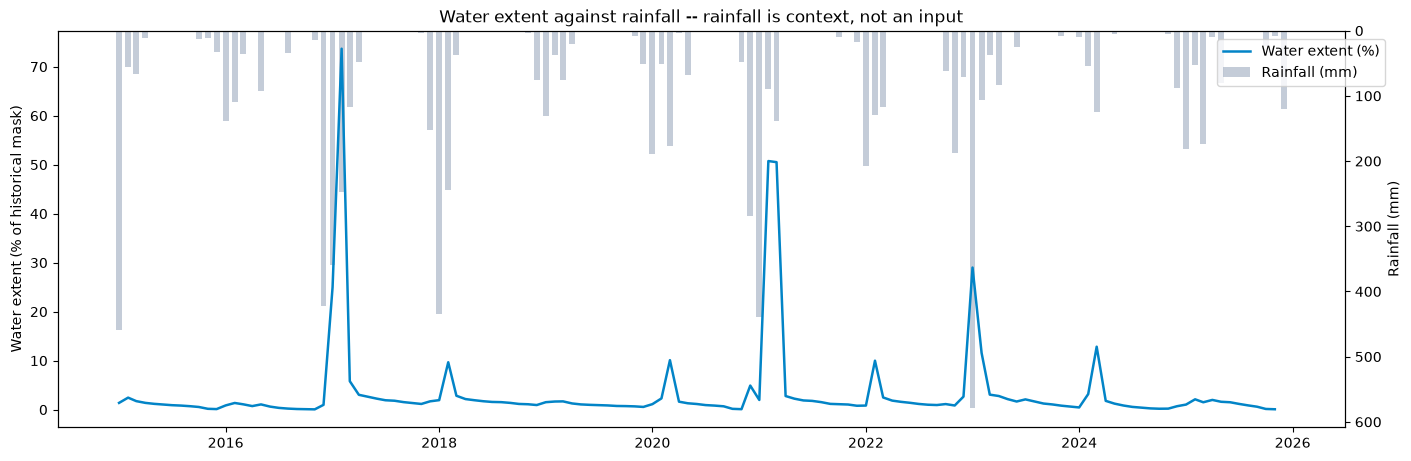

In [4]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib not installed; skipping the plot.")
else:
    fig, ax_water = plt.subplots(figsize=(14, 4.5), constrained_layout=True)

    ax_rain = ax_water.twinx()
    ax_rain.bar(combined.index, combined["rainfall_mm"], width=20,
                color="#94a3b8", alpha=0.55, label="Rainfall (mm)")
    ax_rain.set_ylabel("Rainfall (mm)")
    ax_rain.invert_yaxis()

    ax_water.plot(combined.index, combined["extent_pct"],
                  color="#0284c7", linewidth=1.8, label="Water extent (%)")
    ax_water.set_ylabel("Water extent (% of historical mask)")
    ax_water.set_zorder(ax_rain.get_zorder() + 1)
    ax_water.patch.set_visible(False)

    ax_water.set_title("Water extent against rainfall -- rainfall is context, not an input")
    fig.legend(loc="upper right", bbox_to_anchor=(0.99, 0.94))
    plt.show()

## 3. Proof: rainfall changed nothing

The same AOI and period, run again with `fetch_rainfall=False`. If rainfall
were leaking into the analysis anywhere, something here would differ.

This compares the things rainfall could plausibly have influenced: the regime,
the route, and every detected hydrological-year boundary.

In [5]:
water_only = run_hydroseason(
    output_dir="output/03_rainfall_context_water_only",
    aoi=AOI_PATH,
    aoi_name="Fitzroy River (Kimberley, WA)",
    start_date=START_DATE,
    end_date=END_DATE,
    cache_dir=CACHE_DIR,
    fetch_rainfall=False,
)

assert water_only.analysis.regime.regime == result.analysis.regime.regime
assert water_only.analysis.route == result.analysis.route
assert water_only.extent.equals(result.extent)

with_rain_years = result.analysis.hydro_years
water_only_years = water_only.analysis.hydro_years
assert len(with_rain_years) == len(water_only_years)
assert list(with_rain_years["hy_start"]) == list(water_only_years["hy_start"])
assert list(with_rain_years["hy_end"]) == list(water_only_years["hy_end"])
assert list(with_rain_years["peak_month"]) == list(water_only_years["peak_month"])

print("Identical with and without rainfall:")
print(f"  regime:             {water_only.analysis.regime.regime}")
print(f"  route:              {water_only.analysis.route}")
print(f"  monthly extent:     {len(water_only.extent)} rows, byte-identical")
print(f"  hydrological years: {len(water_only_years)}, same starts/ends/peaks")
print()
print(f"Rainfall status on the water-only run: {water_only.rainfall_status}")

Identical with and without rainfall:
  regime:             seasonal
  route:              per_year_detection
  monthly extent:     132 rows, byte-identical
  hydrological years: 11, same starts/ends/peaks

Rainfall status on the water-only run: disabled


> **Why this is enforced rather than merely intended.** `run_hydroseason`
> resolves the water input, runs `analyze_catchment` on it, and only then
> touches rainfall at all. Rainfall failures — a SILO outage, an AOI it has no
> coverage for, a malformed CSV — are caught, recorded on
> `rainfall_status`/`rainfall_error`, and surfaced as a `UserWarning`. They
> never raise, and they never leave you with a *different* water answer than
> you would have got without rainfall.

## 4. The report

The HTML report gains a collapsible rainfall-comparison panel. Everything
above it — the timeline, the year boundaries, the phases and events — is the
water-only analysis, unchanged.

In [6]:
import os

from IPython.display import IFrame

print(f"HTML: {result.artifacts.html}")

IFrame(src=os.path.relpath(result.artifacts.html, Path.cwd()).replace("\\", "/"),
       width="100%", height=780)

HTML: D:\RLH\5.6\repos\hydroseason\notebooks\output\03_rainfall_context\fitzroy-river-kimberley-wa.html


## Supplying your own rainfall instead

If you already have a rainfall record, pass `rainfall_csv_path=` instead of
`fetch_rainfall=True` (a supplied CSV always wins — SILO is not called at
all). It needs a date column and a millimetres column; see
[Usage Guide: Add rainfall context](https://tayerthiaggo.github.io/hydroseason/guide/#4-add-rainfall-context-optional).

```python
result = run_hydroseason(
    output_dir="output/my_run",
    aoi=AOI_PATH,
    start_date=START_DATE,
    end_date=END_DATE,
    rainfall_csv_path="my_rainfall.csv",
)
```

See also the [Rainfall Context case study](https://tayerthiaggo.github.io/hydroseason/case-studies/rainfall-context/),
which repeats this proof across all five case-study catchments.